<a href="https://colab.research.google.com/github/Eikthyrnir/CatVTON_3DGS/blob/main/CatVTON_3DGS_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CatVTON basic front inference example

## Connect to Google Drive
It is convenient to load data from external source than manually drag it into colab env

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## CatVTON installation

In [2]:
# Клонируем репозиторий CatVTON
%cd /content
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

/content
Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 20.89 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON


In [3]:
# Устанавливаем зависимости из requirements.txt
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-m7jay5wq
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-m7jay5wq
  Resolved https://github.com/huggingface/diffusers.git to commit b003a47354ca3a28b4b21fceb4d649656d8cee99
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (s

In [1]:
# Обновляем accelerate до последней версии (1.13.0) и ставим стабильный diffusers
!pip install -U accelerate==1.13.0 diffusers==0.30.3 peft huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 118.2 MB/s eta 0:00:00
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.39.0.dev0
    Uninstalling diffusers-0.39.0.dev0:
      Successfully uninstalled diffusers-0.39.0.dev0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.31.0
    Uninstalling accelerate-0.31.0:
      Successfully uninstalled accelerate-0.31.0


In [2]:
# Clean up existing conflicting installations first
!pip uninstall -y torch torchvision torchaudio xformers

Found existing installation: torch 2.4.0
Uninstalling torch-2.4.0:
  Successfully uninstalled torch-2.4.0
Found existing installation: torchvision 0.19.0
Uninstalling torchvision-0.19.0:
  Successfully uninstalled torchvision-0.19.0
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [3]:
# Upgrade setuptools to provide the distutils shim required by Python 3.12
!pip install setuptools --upgrade

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 51.0.0
    Uninstalling setuptools-51.0.0:
      Successfully uninstalled setuptools-51.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [4]:
# Upgrade xformers to a version >= 0.0.28.post2 to fix Python 3.12 type annotation errors.
# We must also upgrade torchvision to match the torch 2.5.0 requirement to prevent torchvision::nms CUDA errors.
!pip install torch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 xformers==0.0.28.post2 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 136.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 116.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 15.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 106.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 66.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 145.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 46.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 21.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/2

## CatVTON imports

In [4]:
%cd /content/CatVTON

/content/CatVTON


In [5]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download

import os
import gc

# imports from CatVTON
from model.cloth_masker import AutoMasker
from model.pipeline import CatVTONPipeline

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

## Initializing CatVTON models

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
from diffusers import AutoencoderKL
import torch

weight_dtype = torch.float16

base_model_path = "runwayml/stable-diffusion-inpainting"
catvton_model_path = "zhengchong/CatVTON"

pipeline = CatVTONPipeline(
    base_ckpt=base_model_path,
    attn_ckpt=catvton_model_path,
    attn_ckpt_version="mix",
    weight_dtype=weight_dtype,
    device=device,
    skip_safety_check=True
)

# Fix for the pink mask overlay and brown artifacts on T4:
# We use the official MSE-finetuned VAE which is safe in float16 and maintains high quality.
pipeline.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=weight_dtype).to(device)

# Built-in memory optimization
try:
    pipeline.enable_xformers_memory_efficient_attention()
    print("xformers optimization enabled.")
except Exception:
    print("Using built-in SDPA optimization.")

try:
    if hasattr(pipeline, "enable_model_cpu_offload"):
        pipeline.enable_model_cpu_offload()
        print("CPU offloading enabled!")
except Exception as e:
    print(f"Failed to enable CPU offloading: {e}")

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Downloaded zhengchong/CatVTON to /root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79
Using built-in SDPA optimization.


In [9]:
# Скачиваем основной репозиторий с весами (или берем из кэша)
repo_path = snapshot_download(repo_id="zhengchong/CatVTON")

# Инициализация модуля для автоматического создания масок с использованием путей внутри основного репозитория
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device=device
)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location='cpu')['state_dict']


## Utility functions

In [10]:
def show_try_on_res(person, mask, try_on_result):
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))

    axs[0].imshow(person)
    axs[0].set_title("Front Result (Reference)")
    axs[0].axis('off')

    axs[1].imshow(mask)
    axs[1].set_title("Try-On Mask")
    axs[1].axis('off')

    axs[2].imshow(try_on_result.resize(target_size))
    axs[2].set_title("Try-On Result")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

In [11]:
def show_multiple_images(images):
    n_images = len(images)
    fig, axs = plt.subplots(1, n_images, figsize=(5 * n_images, 6))

    if n_images == 1:
        axs.imshow(images[0])
        axs.axis('off')
    else:
        for i in range(n_images):
            axs[i].imshow(images[i])
            axs[i].axis('off')

    plt.tight_layout()
    plt.show()

In [12]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path

def remove_background_from_all_in_dir(target_dir: Path, automasker):
    for file_path in target_dir.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            img_pil = Image.open(file_path).convert("RGB")

            # Use automasker to get human parsing
            res = automasker(img_pil)

            # schp_atr contains class 0 for background, >0 for human/clothes/etc.
            schp_atr = np.array(res['schp_atr'])

            # Create a binary mask (255 for human, 0 for background)
            mask = (schp_atr > 0).astype(np.uint8) * 255

            # Optional: Smooth the mask slightly to avoid harsh jagged edges
            kernel = np.ones((3, 3), np.uint8)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

            # Convert img to cv2 format (RGB -> BGR for saving)
            img_cv2 = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

            # Apply mask (sets background to pure black)
            img_bg_removed = cv2.bitwise_and(img_cv2, img_cv2, mask=mask)

            # Overwrite the original image in the folder so 3DGS uses the masked version
            cv2.imwrite(str(file_path), img_bg_removed)

In [13]:
import os
import glob
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator


def show_3DGS_loss_curve(log_dir):
    """
    Plots the loss curve from a 1st log file in 3DGS output directory
    log_dir - Path to the 3DGS output directory
    """

    # Find the TensorBoard events file
    event_files = glob.glob(os.path.join(log_dir, "events.out.tfevents*"))

    if not event_files:
        print(f"No TensorBoard event files found in {log_dir}.")
    else:
        print(f"Found event file: {event_files[0]}")
        # Load the event accumulator
        ea = event_accumulator.EventAccumulator(event_files[0])
        ea.Reload()

        # Check available tags (metrics)
        tags = ea.Tags()['scalars']

        # Usually 3DGS logs it under 'train_loss'
        loss_tag = 'train_loss' if 'train_loss' in tags else (tags[0] if tags else None)

        if loss_tag:
            # Extract steps and loss values
            loss_events = ea.Scalars(loss_tag)
            steps = [e.step for e in loss_events]
            losses = [e.value for e in loss_events]

            # Plot the loss curve
            plt.figure(figsize=(10, 6))
            plt.plot(steps, losses, label="Training Loss", color='b', alpha=0.8)
            plt.xlabel("Iterations")
            plt.ylabel("Loss")
            plt.title("3DGS Training Loss over Iterations")
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend()
            plt.show()
        else:
            print("Could not find any loss metrics in the TensorBoard logs.")

## Copy files from drive

In [ ]:
!mkdir /content/clothes

In [14]:
# !cp -r /content/drive/MyDrive/weavella/images/cloth_from_zoolando_website /content/clothes

In [17]:
!gdown 1LFWTuGQ74dZCyQwRQuZIITLtK7S3YtyB -O /content/clothes/cloth_from_zoolando_website.tar
!tar -xf /content/clothes/cloth_from_zoolando_website.tar -C /content/clothes

Downloading...
From: https://drive.google.com/uc?id=1LFWTuGQ74dZCyQwRQuZIITLtK7S3YtyB
To: /content/clothes/cloth_from_zoolando_website.tar
100% 3.26M/3.26M [00:00<00:00, 238MB/s]


# Modifying the U-Net for Reference-Driven Editing (consistent side-view try-on generation)

## Defining custon Reference Attention Processor

In [14]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from diffusers.models.attention_processor import Attention

class ReferenceAttentionProcessor:
    def __init__(self):
        self.is_reference_pass = True
        self.bank_k = []
        self.bank_v = []
        self.step_idx = 0
        self.injection_steps = range(5, 45)

    def clear_bank(self):
        self.bank_k.clear()
        self.bank_v.clear()
        self.step_idx = 0

    def reset_read_index(self):
        self.step_idx = 0

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.Tensor,
        encoder_hidden_states=None,
        attention_mask=None,
        **kwargs,
    ):
        batch_size, sequence_length, _ = hidden_states.shape

        # 1. Get Q, K, V using built-in attention layers
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        # Transform dimensions to 4D for Flash Attention: (batch, heads, seq_len, head_dim)
        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if self.is_reference_pass:
            # ОФФЛОАД НА CPU: сохраняем K и V в оперативную память
            self.bank_k.append(key.clone().detach().cpu())
            self.bank_v.append(value.clone().detach().cpu())
        else:
            # Извлекаем K и V строго для СООТВЕТСТВУЮЩЕГО шага
            if self.step_idx in self.injection_steps and self.step_idx < len(self.bank_k):
                # ВОЗВРАТ НА GPU: переносим нужный тензор обратно в память видеокарты
                ref_k = self.bank_k[self.step_idx].to(key.device)
                ref_v = self.bank_v[self.step_idx].to(value.device)

                # Handle batch mismatch (due to Classifier-Free Guidance)
                if key.shape[0] != ref_k.shape[0]:
                    multiplier = key.shape[0] // ref_k.shape[0]
                    ref_k = ref_k.repeat(multiplier, 1, 1, 1)
                    ref_v = ref_v.repeat(multiplier, 1, 1, 1)

                # Concatenate along the spatial dimension (dim=2 in 4D tensor)
                key = torch.cat([ref_k, key], dim=2)
                value = torch.cat([ref_v, value], dim=2)

            self.step_idx += 1

        # 3. Memory-efficient Attention computation (SDPA)
        # Using 4D tensors enables memory-efficient / Flash Attention in PyTorch
        with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=True):
            try:
                hidden_states = F.scaled_dot_product_attention(
                    query, key, value, dropout_p=0.0, is_causal=False
                )
            except RuntimeError:
                # Fallback to math if necessary
                with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=True, enable_mem_efficient=True):
                    hidden_states = F.scaled_dot_product_attention(
                        query, key, value, dropout_p=0.0, is_causal=False
                    )

        # Reshape back to expected format
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)

        # Linear projections and dropout
        hidden_states = attn.to_out[0](hidden_states)
        if len(attn.to_out) > 1:
            hidden_states = attn.to_out[1](hidden_states)

        return hidden_states

# --- Integration into CatVTON pipeline ---
# 2. Replace standard attention layers in U-Net with our custom one ONLY for up_blocks!
attn_processors = {}
for name in pipeline.unet.attn_processors.keys():
    # Инициализируем наш кастомный процессор только для attn1 в up_blocks
    if "attn1" in name and "up_blocks" in name:
        print(f"replaced attn_processors[{name}] = {pipeline.unet.attn_processors.get(name, None)} with custom attention processor")
        attn_processors[name] = ReferenceAttentionProcessor()
    else:
        # Для всех остальных слоев (включая down_blocks и mid_block) оставляем дефолтные оптимизированные процессоры
        attn_processors[name] = pipeline.unet.attn_processors[name]

pipeline.unet.set_attn_processor(attn_processors)


replaced attn_processors[up_blocks.1.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.1.attentions.1.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.1.attentions.2.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.1.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.2.attentions.2.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn_processors[up_blocks.3.attentions.0.transformer_blocks.0.attn1.processor] = AttnProcessor2_0() with custom attention processor
replaced attn

# Complete pipeline test on vadim video

## Install camenduru 3DGS (3DGS version for colab)

In [19]:
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile ninja

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 603, done.
remote: Total 603 (delta 0), reused 0 (delta 0), pack-reused 603 (from 1)
Receiving objects: 100% (603/603), 2.09 MiB | 64.91 MiB/s, done.
Resolving deltas: 100% (346/346), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects: 100% (174/174), done.        
remote: Total 3293 (delta 171), reused 280 (delta 148), pack-reused 2971 (from 1)        
Receiving objects:

In [20]:
%cd /content/gaussian-splatting

/content/gaussian-splatting


In [21]:
import sys
!{sys.executable} -m pip install setuptools==69.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.5/819.5 kB 45.1 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [22]:
!{sys.executable} -m pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization

  Preparing metadata (setup.py) ... done


In [23]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'

In [24]:
!sed -i '1i #include <float.h>' /content/gaussian-splatting/submodules/simple-knn/simple_knn.cu

%cd /content/gaussian-splatting
!pip install ./submodules/simple-knn

/content/gaussian-splatting
Processing ./submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=simple_knn-0.0.0-cp312-cp312-linux_x86_64.whl size=3069661 sha256=94caaae56f252481a6c3fd8fafa3b702eb851e373ba6de390f6d3abe936d7810
  Stored in directory: /root/.cache/pip/wheels/0a/f2/1b/255828ebad94ea248378281b7926639d83ce4f394f0052800d
Successfully built simple_knn


## Split video into images

In [25]:
!mkdir -p /content/gaussian-splatting/input/vadim
# !cp /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/vadim.MOV /content/gaussian-splatting/input/vadim/
!gdown 1MPlCmym-gT7Gndj92rsbMxIJMJF-rQhX -O /content/gaussian-splatting/input/vadim/

Downloading...
From: https://drive.google.com/uc?id=1MPlCmym-gT7Gndj92rsbMxIJMJF-rQhX
To: /content/gaussian-splatting/input/vadim/vadim.MOV
100% 11.1M/11.1M [00:01<00:00, 7.98MB/s]


In [26]:
!mkdir -p /content/gaussian-splatting/input/vadim/init_frames
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/init_frames/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## Init front/back cloth and user images

In [21]:
target_size = (768, 1024)

In [22]:
# different front-back
garment_folder = "/content/clothes/cloth_from_zoolando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# pure flat-out t-shirt image
front_garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
back_garment_path  = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)

In [23]:
# different front-back + side image
garment_folder = "/content/clothes/cloth_from_zoolando_website/the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11"

# front_garment_path = garment_folder + "/e8cb036024b94af8aaeb5b8d38dfcb7c.webp" # pure flat-out t-shirt image
front_garment_path = garment_folder + "/e3c8055f31754cbbbeff96938543fdc1.webp" # on person
# back_garment_path  = garment_folder + "/95c143c6284549e99409498bf1b92679.webp" # pure flat-out t-shirt image
back_garment_path  = garment_folder + "/0c220ec6788a456194fa5184802d1743.webp" # on person
side_garment_path  = garment_folder + "/c172d2683ba54fe299fdbc6b5023658d.webp" # on person

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

In [24]:
person_folder = "/content/gaussian-splatting/input/vadim/init_frames"

front_person_path = person_folder + "/0011.jpg"
back_person_path  = person_folder + "/0041.jpg"

# Load and resize
front_person_img = Image.open(front_person_path).convert("RGB").resize(target_size)
back_person_img  = Image.open(back_person_path).convert("RGB").resize(target_size)

## Funcs to determine body position/rotation

### Custom mask generators

In [25]:
def schp_refine_mask(coarse_result, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement ---
    print("Phase 2: Refining Mask from Coarse Result...")
    # Run automasker on the coarse result to get exact boundaries of the new garment
    fine_mask_result = automasker(coarse_result)

    # Extract both SCHP lip and SCHP atr maps
    schp_lip = np.array(fine_mask_result['schp_lip'])
    schp_atr = np.array(fine_mask_result['schp_atr'])

    # Extract Upper-clothes from both models (LIP index 5, ATR index 4)
    lip_upper = (schp_lip == 5).astype(np.uint8) * 255
    atr_upper = (schp_atr == 4).astype(np.uint8) * 255

    # Evaluate which mask is "better" (heuristic: largest area)
    # This avoids compounding false positives while effectively avoiding the mask with a huge hole.
    lip_area = np.sum(lip_upper > 0)
    atr_area = np.sum(atr_upper > 0)

    if lip_area > atr_area:
        print(f"  -> Selecting LIP upper-clothes mask (larger area: {lip_area} vs {atr_area})")
        upper_clothes_mask = lip_upper
    else:
        print(f"  -> Selecting ATR upper-clothes mask (larger area: {atr_area} vs {lip_area})")
        upper_clothes_mask = atr_upper

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise in the background)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes (like the ear-sized hole) using Contours
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays" or boundary holes
    if close_ksize > 0:
        kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
        closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    else:
        closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair) ---
    # ATR Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(schp_atr, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")
    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

In [26]:
# Install transformers if it's not already installed
!pip install -q transformers

from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)

def segformer_refine_mask(coarse_result, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement (SegFormer) ---
    print("Phase 2: Refining Mask from Coarse Result using SegFormer...")

    # Run SegFormer on the coarse result image
    inputs = processor(images=coarse_result, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu()
    upsampled_logits = nn.functional.interpolate(
        logits,
        size=coarse_result.size[::-1], # (W, H) -> (H, W)
        mode="bilinear",
        align_corners=False,
    )
    pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()

    # Segformer B2 Clothes Upper-clothes class is 4
    upper_clothes_mask = (pred_seg == 4).astype(np.uint8) * 255

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes using Contours (Less necessary for SegFormer, but good for safety)
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays"
    if close_ksize > 0:
        kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
        closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    else:
        closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair, Scarves) ---
    # SegFormer Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(pred_seg, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")

    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

### 2 phase try-on:
1. low number of steps for try-on with big garment-agnostic mask
2. generate tight mask basing on coare try-on result from step 1
3. use tight mask with normal number of steps to produce final try-on

In [27]:
def two_phase_tryon(person_img, garment_img, automasker, pipeline, mask_refiner_fun, is_ref_pass=True, coarse_steps=50, fine_steps=50, seed=42):
    # --- Phase 1: Coarse Try-On ---
    print("Phase 1: Generating Coarse Mask and Try-On...")
    coarse_mask_result = automasker(person_img)
    coarse_mask = coarse_mask_result['mask']

    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = is_ref_pass
            if is_ref_pass:
                proc.clear_bank()
            else:
                proc.reset_read_index()

    generator = torch.Generator(device=device).manual_seed(seed)
    coarse_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=coarse_mask,
        num_inference_steps=coarse_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    refined_mask, masks_inbetween = mask_refiner_fun(coarse_result)

    # --- Phase 3: Final Fine Try-On ---
    print("Phase 3: Final High-Res Try-On with Refined Mask...")

    generator = torch.Generator(device=device).manual_seed(seed)

    for proc in pipeline.unet.attn_processors.values():
        if isinstance(proc, ReferenceAttentionProcessor):
            proc.is_reference_pass = is_ref_pass
            if is_ref_pass:
                proc.clear_bank()
            else:
                proc.reset_read_index()

    final_result = pipeline(
        image=person_img,
        condition_image=garment_img,
        mask=refined_mask,
        num_inference_steps=fine_steps,
        guidance_scale=2.5,
        generator=generator
    )[0]

    # Return all intermediate masks and final results
    return coarse_result, refined_mask, final_result, masks_inbetween

In [28]:
def determine_view_angle(densepose_img):
    """
    Determines if the person is facing front, back, or side based on DensePose segmentation.
    """
    densepose_array = np.array(densepose_img)

    front_torso_pixels = np.sum(densepose_array == 2)
    back_torso_pixels = np.sum(densepose_array == 1)

    total_torso = front_torso_pixels + back_torso_pixels

    if total_torso == 0:
        return "unknown"

    # Simple heuristic to determine the angle
    if front_torso_pixels > back_torso_pixels * 2:
        return "front"
    elif back_torso_pixels > front_torso_pixels * 2:
        return "back"
    else:
        return "side"

/usr/local/lib/python3.12/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


DensePose parts and their pixel counts for the front view:
Part 2: 48917 pixels
Part 3: 2379 pixels
Part 4: 2586 pixels
Part 5: 4062 pixels
Part 6: 4322 pixels
Part 9: 9404 pixels
Part 10: 8495 pixels
Part 13: 5674 pixels
Part 14: 5966 pixels
Part 15: 3791 pixels
Part 16: 3729 pixels
Part 17: 1699 pixels
Part 18: 1648 pixels
Part 19: 1927 pixels
Part 20: 1721 pixels
Part 21: 2745 pixels
Part 22: 2111 pixels
Part 23: 6900 pixels
Part 24: 6002 pixels


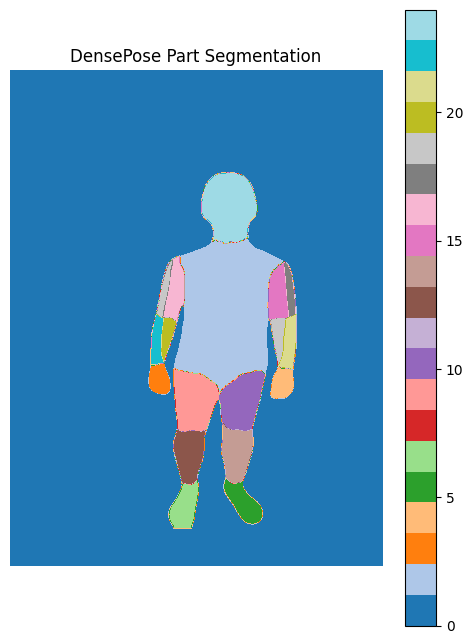

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# The mask_result from automasker contains 'densepose' along with 'mask'
# Let's run automasker on the front image to inspect it
automasker_res = automasker(front_person_img)
densepose_img = np.array(automasker_res['densepose'])

# Find unique part indices and their pixel counts
unique_parts, counts = np.unique(densepose_img, return_counts=True)
print("DensePose parts and their pixel counts for the front view:")
for part, count in zip(unique_parts, counts):
    # 0 is usually background
    if part != 0:
        print(f"Part {part}: {count} pixels")

# Visualize the DensePose map
plt.figure(figsize=(6, 8))
plt.imshow(densepose_img, cmap='tab20')
plt.title("DensePose Part Segmentation")
plt.colorbar()
plt.axis('off')
plt.show()

# By observing which part index has the most pixels in the torso area for front vs back views,
# we can create a simple heuristic to determine the angle!

## YOLOv8n-pose to get body keypoints

In [40]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 130.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.1 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 12.0 which is incompatible.
tobler 0.14.0 requires tqdm>=4.67, but you have tqdm 4.66.4 which is incompatible.


In [30]:
import cv2
import math
import numpy as np
from ultralytics import YOLO

# 1. Initialize YOLOv8 Pose Model (using nano for speed, can be changed to yolov8x-pose.pt for highest accuracy)
pose_predictor = YOLO('yolov8n-pose.pt')

# 2. Function to extract shoulder width and keypoints
def get_yolov8n_shoulder_width_and_kpts(img_pil):
    # Convert PIL RGB to OpenCV BGR
    img_bgr = np.array(img_pil)[:, :, ::-1]

    # Run YOLOv8 pose inference
    results = pose_predictor(img_bgr, verbose=False)

    if len(results) == 0 or results[0].keypoints is None or len(results[0].keypoints.data) == 0:
        return None, np.zeros((17, 3))

    # Get keypoints for the first detected person
    # YOLOv8 format: [num_persons, 17, 3] where 3 is (x, y, confidence)
    keypoints = results[0].keypoints.data[0].cpu().numpy()

    # COCO format: 5 is Left Shoulder, 6 is Right Shoulder
    l_shoulder = keypoints[5]
    r_shoulder = keypoints[6]

    # YOLOv8 confidence scores are normalized 0-1, so 0.3 is a reasonable threshold
    if l_shoulder[2] > 0.3 and r_shoulder[2] > 0.3:
        # 2D Euclidean distance (accounts for tilt/lean)
        width = math.hypot(l_shoulder[0] - r_shoulder[0], l_shoulder[1] - r_shoulder[1])
        return width, keypoints
    return None, keypoints


## Determine body positions per frame

In [31]:
# Get all image files in person_folder excluding front_person_path
all_files = [
    os.path.join(person_folder, f)
    for f in os.listdir(person_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

In [32]:
body_params = {}
for file_path in all_files:
    print(f"processing {file_path}")
    person_img = Image.open(file_path).convert("RGB")

    automasker_res = automasker(person_img)
    densepose_img = np.array(automasker_res['densepose'])

    body_params[file_path] = {'view_type': determine_view_angle(densepose_img)}
    # calculate angle
    shoulder_width, front_kpts = get_yolov8n_shoulder_width_and_kpts(person_img)
    body_params[file_path]['shoulder_width'] = shoulder_width

processing /content/gaussian-splatting/input/vadim/init_frames/0001.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0002.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0027.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0026.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0048.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0023.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0005.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0012.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0041.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0047.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0033.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0055.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0025.jpg
processing /content/gaussian-splatting/input/vadim/init_frames/0

## Front/Back split Try-on per frame
This takes a lot of time! You can skip this and just download the results archive from Google Drive: [cell 'Download try-on results from Google Drive'](https://colab.research.google.com/github/Eikthyrnir/CatVTON_3DGS/blob/main/CatVTON_3DGS_pipeline.ipynb#scrollTo=GagRKKpNqbmO&line=1&uniqifier=1)

In [ ]:
front_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(front_person_path)
                         and body_params[f]['view_type'] == 'front'
                       ],
                      key=os.path.basename)
back_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'back'
                       ],
                      key=os.path.basename)
side_images = sorted([f for f in all_files
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'side'
                       ],
                      key=os.path.basename)

In [ ]:
front_images_try_on_targets = front_images[::5]
back_images_try_on_targets = back_images[::5]

In [ ]:
NUM_INFERENCE_STEPS_CAT_VTON = 50

In [ ]:
output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
os.makedirs(output_folder, exist_ok=True)

### side try-on

In [ ]:
for person_path in side_images:
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        side_garment_image,
        automasker,
        pipeline,
        # naive_schp_refine_mask, # often bad results
        schp_refine_mask,
        # segformer_refine_mask,
        is_ref_pass=True
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

### front try-on

In [ ]:
# Generate masks using automasker

print("--- PASS 1: Reference Generation (Front) ---")

# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    front_person_img,
    front_garment_image,
    automasker,
    pipeline,
    schp_refine_mask, # segformer_refine_mask
    is_ref_pass=True
)

show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

# Save the front result as well to complete the set
filename = os.path.basename(front_person_path)
output_path = os.path.join(output_folder, filename)
final_res.save(output_path)
print(f"\nSaved front result to: {output_path}")

In [ ]:
for person_path in front_images: # Process every 10th image
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        front_garment_image,
        automasker,
        pipeline,
        schp_refine_mask, # segformer_refine_mask
        is_ref_pass=False
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

### back try-on

In [ ]:
# Generate masks using automasker

print("--- PASS 1: Reference Generation (Back) ---")

# Run the two-phase pipeline with the new SegFormer refinement
coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
    back_person_img,
    back_garment_image,
    automasker,
    pipeline,
    schp_refine_mask, # segformer_refine_mask
    is_ref_pass=True
)

show_multiple_images((front_person_img, coarse_res, refined_mask, final_res))
show_multiple_images(masks_refinement_steps)

# Save the front result as well to complete the set
filename = os.path.basename(back_person_path)
output_path = os.path.join(output_folder, filename)
final_res.save(output_path)
print(f"\nSaved front result to: {output_path}")

In [ ]:
for person_path in back_images: # Process every 10th image
    person_img = Image.open(person_path).convert("RGB").resize(target_size)

    # Run the two-phase pipeline with the new SegFormer refinement
    coarse_res, refined_mask, final_res, masks_refinement_steps = two_phase_tryon(
        person_img,
        back_garment_image,
        automasker,
        pipeline,
        schp_refine_mask, # segformer_refine_mask
        is_ref_pass=False
    )

    show_multiple_images((person_img, coarse_res, refined_mask, final_res))
    show_multiple_images(masks_refinement_steps)

    # Save the front result as well to complete the set
    filename = os.path.basename(person_path)
    output_path = os.path.join(output_folder, filename)
    final_res.save(output_path)
    print(f"\nSaved front result to: {output_path}")

### Copy try-on results folder to Google Drive

In [ ]:
!mkdir -p /content/drive/MyDrive/weavella/try_on_results
!tar -cf /content/drive/MyDrive/weavella/try_on_results/2_phase_vadim_2fps_the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11.tar \
    -C /content/gaussian-splatting/input/vadim/try_on_res input

## Download try-on results from Google Drive

In [50]:
!mkdir -p /content/try_on_results
!gdown 1JMdPFAw8tWM4eGDOoMIqAOTE2wsgemBS \
    -O /content/try_on_results/2_phase_vadim_2fps_the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11.tar

Downloading...
From: https://drive.google.com/uc?id=1JMdPFAw8tWM4eGDOoMIqAOTE2wsgemBS
To: /content/try_on_results/2_phase_vadim_2fps_the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11.tar
100% 3.71M/3.71M [00:00<00:00, 314MB/s]
tar: /content/gaussian-splatting/input/vadim/try_on_res/input: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [51]:
# unpack try-on result images
!mkdir -p /content/gaussian-splatting/input/vadim/try_on_res/input
!tar -xf /content/try_on_results/2_phase_vadim_2fps_the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11.tar \
    --strip-components=1 \
    -C /content/gaussian-splatting/input/vadim/try_on_res/input

## Run 3DGS training

### Install GPU-accelerated COLMAP

In [39]:
# All of these is to use GPU-accelerated version of COLMAP

# Install xvfb for OpenGL virtual display and required dependencies to build COLMAP
!sudo apt-get update
!sudo apt-get install -y xvfb cmake ninja-build \
    libboost-program-options-dev libboost-filesystem-dev libboost-graph-dev \
    libboost-system-dev libboost-test-dev libsuitesparse-dev \
    libfreeimage-dev libgoogle-glog-dev libgflags-dev \
    libglew-dev libqt5opengl5-dev qt5-qmake qtbase5-dev libceres-dev \
    libflann-dev libcgal-dev libmetis-dev

# Build COLMAP from source for GPU (CUDA) support
!rm -rf /content/colmap
!git clone --branch 3.9 https://github.com/colmap/colmap.git /content/colmap
%cd /content/colmap
!mkdir build
%cd build
!cmake .. -GNinja -DCUDA_ENABLED=ON -DCMAKE_BUILD_TYPE=Release -DCMAKE_CUDA_ARCHITECTURES=native
!ninja
!sudo ninja install

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,701 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,090 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/u

### Create 3DGS model of vanila vadim

#### Run COLMAP

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim/vanilla/input
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/vanilla/input/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/vanilla

/content/gaussian-splatting
I0525 12:25:36.944895  9131 misc.cc:198] 
Feature extraction
I0525 12:25:37.230500  9141 feature_extraction.cc:254] Processed file [1/58]
I0525 12:25:37.230548  9141 feature_extraction.cc:257]   Name:            0001.jpg
I0525 12:25:37.230552  9141 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0525 12:25:37.230556  9141 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0525 12:25:37.230573  9141 feature_extraction.cc:289]   Focal Length:    1536.00px
I0525 12:25:37.230585  9141 feature_extraction.cc:302]   Features:        4315
I0525 12:25:37.265372  9141 feature_extraction.cc:254] Processed file [2/58]
I0525 12:25:37.265420  9141 feature_extraction.cc:257]   Name:            0002.jpg
I0525 12:25:37.265424  9141 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0525 12:25:37.265427  9141 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0525 12:25:37.265432  9141 feature_extraction.cc:289]   Focal Length:    1536.00px
I0

In [52]:
!mkdir -p /content/drive/MyDrive/weavella/3DGS_results/COLMAP_results
!tar -cf /content/drive/MyDrive/weavella/3DGS_results/COLMAP_results/vanilla_vadim_COLMAP_2fps_with_bg.tar \
    -C /content/gaussian-splatting/input/vadim vanilla

tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted/sparse/0/cameras.bin: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted/sparse/0/images.bin: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted/sparse/0/points3D.bin: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted/sparse/0/project.ini: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted/sparse/0: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted/sparse: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted/database.db: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/distorted: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/images/0002.jpg: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/images/0008.jpg: file changed as we read it
tar: vanilla_vadim_COLMAP_2fps_with_bg/images/0005.jpg: file changed as we read it
tar: vanilla_vadim_COLM

#### Load COLMAP from Google Drive

In [53]:
!mkdir -p /content/gaussian-splatting/input/vadim/vanilla/
!gdown 1Y6fq0wR5Xs7_X55akFe3Ml_Px65W2tkz -O /content/gaussian-splatting/input/vadim/vanilla/vanilla_vadim_COLMAP_2fps_with_bg.tar

Downloading...
From: https://drive.google.com/uc?id=1Y6fq0wR5Xs7_X55akFe3Ml_Px65W2tkz
To: /content/gaussian-splatting/input/vadim/vanilla/vanilla_vadim_COLMAP_2fps_with_bg.tar
100% 88.8M/88.8M [00:00<00:00, 295MB/s]


In [54]:
!tar -xf /content/gaussian-splatting/input/vadim/vanilla/vanilla_vadim_COLMAP_2fps_with_bg.tar \
    --strip-components=1 \
    -C /content/gaussian-splatting/input/vadim/vanilla

### Detect True Front using Depth Anything V2
Instead of pixel width (which is vulnerable to camera distance), we calculate the Z-depth of both shoulders. The image where `abs(left_shoulder_depth - right_shoulder_depth)` is closest to 0 represents the most perfectly aligned front view.

In [33]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

# Load Depth Anything V2 model
depth_image_processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")
depth_model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf").to(device)

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

In [34]:
def get_shoulder_depth_diff(img_pil, keypoints):
    # keypoints format: [17, 3] from Detectron2 (x, y, score)
    # 5 is Left Shoulder, 6 is Right Shoulder
    l_shoulder = keypoints[5]
    r_shoulder = keypoints[6]

    # Prepare image for depth model
    inputs = depth_image_processor(images=img_pil, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = depth_model(**inputs)
        predicted_depth = outputs.predicted_depth

    # Interpolate to original size
    prediction = torch.nn.functional.interpolate(
        predicted_depth.unsqueeze(1),
        size=img_pil.size[::-1],
        mode="bicubic",
        align_corners=False,
    )

    depth_map = prediction.squeeze().cpu().numpy()

    # Get depth at shoulder coordinates (y, x)
    # Note: image coordinates are (x, y), numpy array is [y, x]
    l_x, l_y = int(l_shoulder[0]), int(l_shoulder[1])
    r_x, r_y = int(r_shoulder[0]), int(r_shoulder[1])

    # Ensure coordinates are within bounds
    h, w = depth_map.shape
    l_x, l_y = np.clip(l_x, 0, w-1), np.clip(l_y, 0, h-1)
    r_x, r_y = np.clip(r_x, 0, w-1), np.clip(r_y, 0, h-1)

    l_depth = depth_map[l_y, l_x]
    r_depth = depth_map[r_y, r_x]

    return abs(l_depth - r_depth)

In [35]:
person_folder = "/content/gaussian-splatting/input/vadim/vanilla/images"

# Get all image files in person_folder excluding front_person_path
all_files = [
    os.path.join(person_folder, f)
    for f in os.listdir(person_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]
body_params = {}
for file_path in all_files:
    print(f"processing {file_path}")
    person_img = Image.open(file_path).convert("RGB")

    automasker_res = automasker(person_img)
    densepose_img = np.array(automasker_res['densepose'])

    body_params[file_path] = {'view_type': determine_view_angle(densepose_img)}

processing /content/gaussian-splatting/input/vadim/vanilla/images/0001.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0002.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0027.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0026.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0048.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0023.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0005.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0012.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0041.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0047.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0033.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0055.jpg
processing /content/gaussian-splatting/input/vadim/vanilla/images/0025.jpg
processing /content/gauss

In [38]:
min_depth_diff = float('inf')
new_true_front_img_name = None
shoulder_depth_diffs = {}

print("Evaluating front images based on shoulder depth difference and keypoint visibility...")
for file_path in all_files:
    if body_params[file_path]['view_type'] == 'front':
        img_pil = Image.open(file_path).convert("RGB")
        width, kpts = get_yolov8n_shoulder_width_and_kpts(img_pil)

        if width is not None:
            # Add visibility & width checks to filter out false 'front' detections
            l_score = kpts[5][2]
            r_score = kpts[6][2]

            # Thresholds: reject if confidence is too low OR if width is suspiciously small
            # (e.g. less than 60% of the maximum shoulder width found previously)
            if l_score < 0.2 or r_score < 0.2 or width < (np.max(width) * 0.6):
                continue

            diff = get_shoulder_depth_diff(img_pil, kpts)
            img_name = os.path.basename(file_path)
            shoulder_depth_diffs[img_name] = diff

            if diff < min_depth_diff:
                min_depth_diff = diff
                new_true_front_img_name = img_name

# Override the true_front_img_name for the next pipeline steps
true_front_img_name = new_true_front_img_name

print(f"\nTrue front image detected (Depth Method): {true_front_img_name} with depth difference {min_depth_diff:.4f}")

# Sort and display (closest to 0 is better)
sorted_shoulder_diffs = dict(sorted(shoulder_depth_diffs.items(), key=lambda item: item[1]))
print("\nShoulder depth differences (sorted):")
for name, d in sorted_shoulder_diffs.items():
    print(f"{name}: {d:.4f}")


Evaluating front images based on shoulder depth difference and keypoint visibility...

True front image detected (Depth Method): 0012.jpg with depth difference 0.1380

Shoulder depth differences (sorted):
0012.jpg: 0.1380
0011.jpg: 0.1457
0054.jpg: 0.1779
0024.jpg: 0.2525
0010.jpg: 0.3425
0013.jpg: 0.3824
0014.jpg: 0.6448
0056.jpg: 0.6834
0009.jpg: 0.7294
0015.jpg: 0.9542
0057.jpg: 0.9862
0002.jpg: 1.0258
0008.jpg: 1.1008
0023.jpg: 1.1314
0003.jpg: 1.1564
0001.jpg: 1.1892
0055.jpg: 1.2017
0022.jpg: 1.2086
0021.jpg: 1.2308
0004.jpg: 1.2534
0058.jpg: 1.2863
0016.jpg: 1.2975
0007.jpg: 1.3908
0006.jpg: 1.5269
0020.jpg: 1.6292
0018.jpg: 1.6385
0017.jpg: 1.6560
0005.jpg: 1.6726
0019.jpg: 1.7634


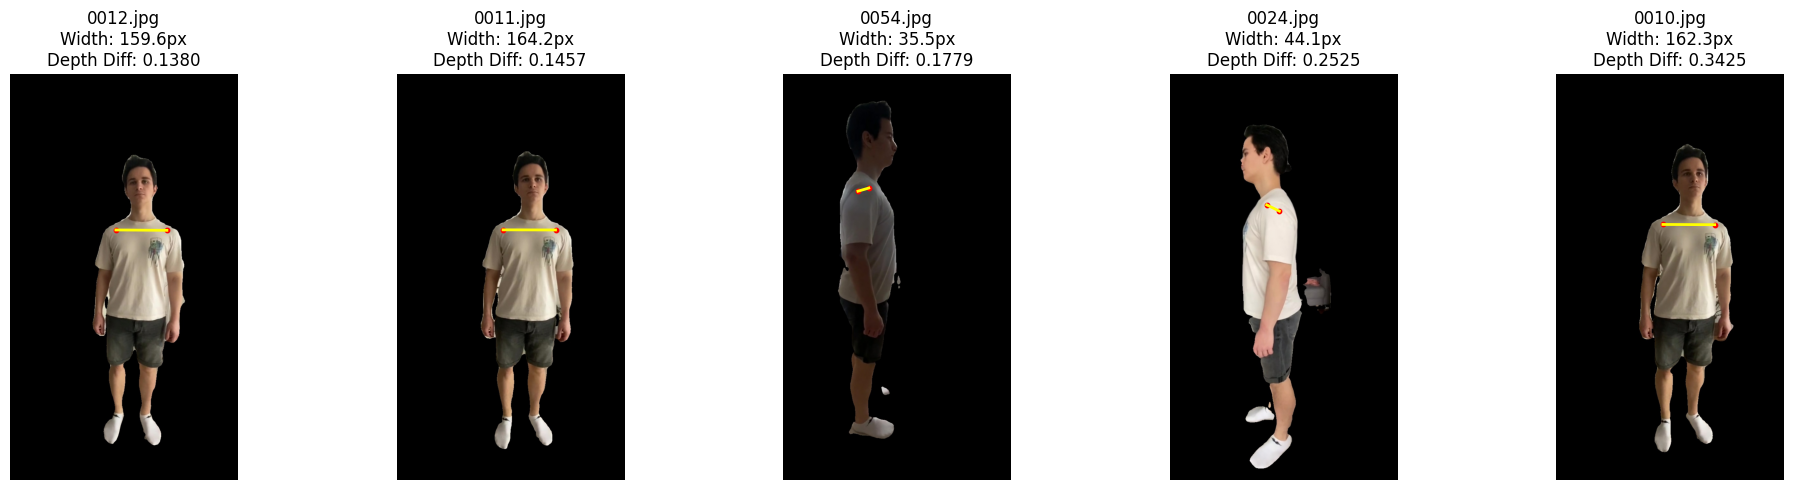

In [39]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Let's visualize the top 5 images with the lowest shoulder depth difference (best front views)
top_images = list(sorted_shoulder_diffs.keys())[:5]

fig, axes = plt.subplots(1, len(top_images), figsize=(20, 5))

for ax, img_name in zip(axes, top_images):
    img_path = os.path.join(person_folder, img_name)
    img_pil = Image.open(img_path).convert("RGB")

    # Get keypoints
    width, kpts = get_yolov8n_shoulder_width_and_kpts(img_pil)

    ax.imshow(img_pil)

    if width is not None:
        # 5: Left Shoulder, 6: Right Shoulder (x, y, conf)
        l_x, l_y = kpts[5][0], kpts[5][1]
        r_x, r_y = kpts[6][0], kpts[6][1]

        ax.scatter([l_x, r_x], [l_y, r_y], c='red', s=10, marker='o')
        ax.plot([l_x, r_x], [l_y, r_y], c='yellow', linestyle='-', linewidth=2)
        ax.set_title(f"{img_name}\nWidth: {width:.1f}px\nDepth Diff: {sorted_shoulder_diffs[img_name]:.4f}")
    else:
        ax.set_title(f"{img_name}\n(Not detected)")

    ax.axis('off')

plt.tight_layout()
plt.show()

### Detect True Front using MediaPipe 3D Pose Landmarks
Instead of a 2D pose model + depth estimation model, MediaPipe provides a `z` coordinate directly out-of-the-box which estimates the landmark depth relative to the subject's center of mass. We can find the image where `abs(left_shoulder.z - right_shoulder.z)` is minimized.

In [40]:
!pip install -q mediapipe

In [41]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request
from PIL import Image
import sys

# Download the model asset if it doesn't exist
model_path = 'pose_landmarker_heavy.task'
if not os.path.exists(model_path):
    urllib.request.urlretrieve('https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task', model_path)

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Initialize MediaPipe Pose Landmarker
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5)
detector = vision.PoseLandmarker.create_from_options(options)

def get_mediapipe_shoulder_info(img_pil):
    # Convert PIL to NumPy array (MediaPipe expects RGB, which PIL provides)
    img_np = np.array(img_pil)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_np)

    detection_result = detector.detect(mp_image)

    if not detection_result.pose_landmarks:
        return None, None, None

    landmarks = detection_result.pose_landmarks[0]
    # MediaPipe Pose: 11 is Left Shoulder, 12 is Right Shoulder
    l_shoulder = landmarks[11]
    r_shoulder = landmarks[12]

    # Visibility check (0.0 to 1.0)
    if l_shoulder.visibility < 0.5 or r_shoulder.visibility < 0.5:
        return None, None, None

    # x, y are normalized [0.0, 1.0]. Multiply by dimensions for pixel coords
    h, w, _ = img_np.shape
    l_x, l_y = l_shoulder.x * w, l_shoulder.y * h
    r_x, r_y = r_shoulder.x * w, r_shoulder.y * h

    # 2D Width in pixels
    width = math.hypot(l_x - r_x, l_y - r_y)

    # Calculate depth difference using MediaPipe's intrinsic z coordinate
    # Z is roughly the depth in 'image scale' relative to the hips
    depth_diff = abs(l_shoulder.z - r_shoulder.z)

    coords = {
        'left': (l_x, l_y),
        'right': (r_x, r_y)
    }
    return width, depth_diff, coords


In [42]:
mp_min_depth_diff = float('inf')
mp_true_front_img_name = None
mp_shoulder_depth_diffs = {}
mp_shoulder_coords = {}
mp_shoulder_widths = {}

# Initialize max_width on the fly
max_width = 0.0

print("Evaluating front images based on MediaPipe 3D shoulder depth difference...")
for file_path in all_files:
    # Use the initial mask filter to process only rough front candidates
    if body_params[file_path]['view_type'] == 'front':
        img_pil = Image.open(file_path).convert("RGB")
        width, depth_diff, coords = get_mediapipe_shoulder_info(img_pil)

        if width is not None:
            # Update max_width dynamically
            max_width = max(max_width, width)

            # Optional width filter to ignore obvious false positives
            if width < (max_width * 0.6):
                continue

            img_name = os.path.basename(file_path)
            mp_shoulder_depth_diffs[img_name] = depth_diff
            mp_shoulder_coords[img_name] = coords
            mp_shoulder_widths[img_name] = width

            if depth_diff < mp_min_depth_diff:
                mp_min_depth_diff = depth_diff
                mp_true_front_img_name = img_name

print(f"\nTrue front image detected (MediaPipe 3D Method): {mp_true_front_img_name} with Z-depth difference {mp_min_depth_diff:.4f}")

# Sort and display (closest to 0 is better)
mp_sorted_shoulder_diffs = dict(sorted(mp_shoulder_depth_diffs.items(), key=lambda item: item[1]))
print("\nMediaPipe Shoulder depth differences (sorted):")
for name, d in mp_sorted_shoulder_diffs.items():
    print(f"{name}: {d:.4f}")


Evaluating front images based on MediaPipe 3D shoulder depth difference...

True front image detected (MediaPipe 3D Method): 0011.jpg with Z-depth difference 0.0111

MediaPipe Shoulder depth differences (sorted):
0011.jpg: 0.0111
0012.jpg: 0.0534
0010.jpg: 0.1011
0009.jpg: 0.1190
0013.jpg: 0.1860
0014.jpg: 0.2590
0008.jpg: 0.2668
0015.jpg: 0.3583
0016.jpg: 0.4004
0007.jpg: 0.4157
0017.jpg: 0.4885
0006.jpg: 0.5176
0005.jpg: 0.5579
0018.jpg: 0.5817
0001.jpg: 0.6100
0004.jpg: 0.6103
0002.jpg: 0.6179
0019.jpg: 0.6960


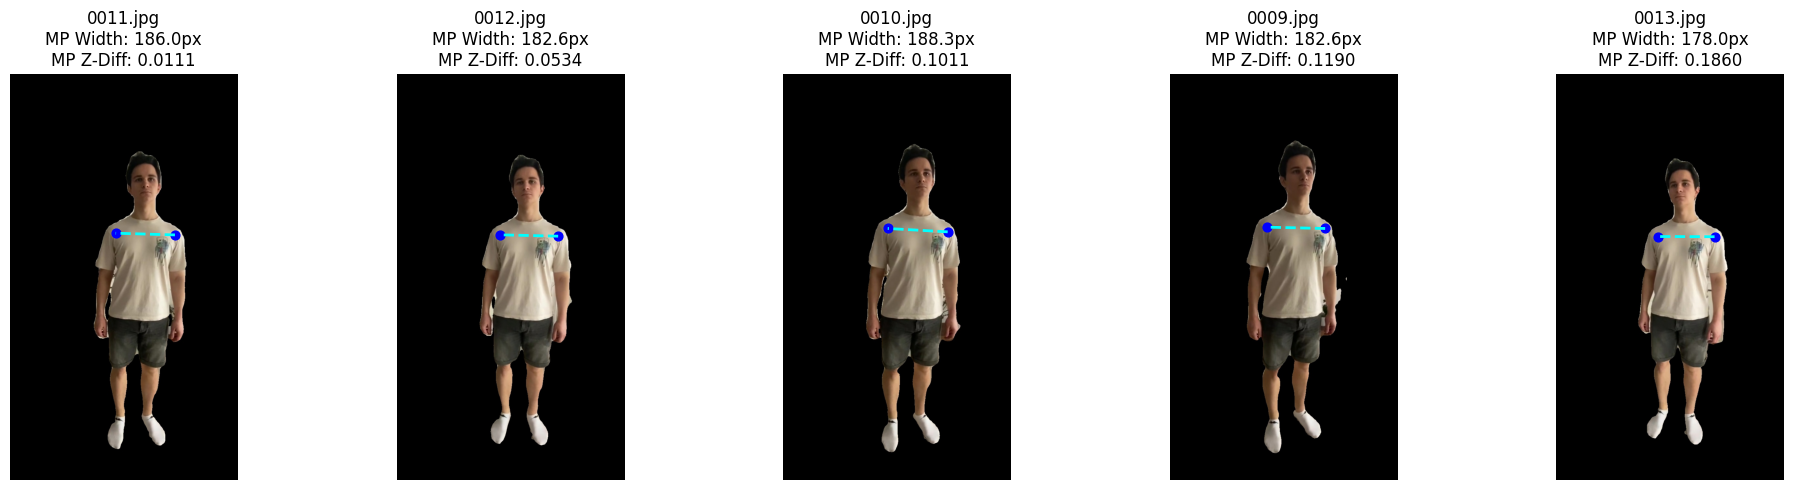

In [43]:
# Let's visualize the top 5 images with the lowest shoulder depth difference (MediaPipe)
mp_top_images = list(mp_sorted_shoulder_diffs.keys())[:5]

fig, axes = plt.subplots(1, len(mp_top_images), figsize=(20, 5))
if len(mp_top_images) == 1:
    axes = [axes]

for ax, img_name in zip(axes, mp_top_images):
    img_path = os.path.join(person_folder, img_name)
    img_pil = Image.open(img_path).convert("RGB")

    coords = mp_shoulder_coords.get(img_name)
    width = mp_shoulder_widths.get(img_name)
    depth_diff = mp_shoulder_depth_diffs.get(img_name)

    ax.imshow(img_pil)

    if coords is not None:
        l_x, l_y = coords['left']
        r_x, r_y = coords['right']

        # Use blue/cyan to distinguish from the YOLOv8 red/yellow visualization
        ax.scatter([l_x, r_x], [l_y, r_y], c='blue', s=40, marker='o')
        ax.plot([l_x, r_x], [l_y, r_y], c='cyan', linestyle='--', linewidth=2)
        ax.set_title(f"{img_name}\nMP Width: {width:.1f}px\nMP Z-Diff: {depth_diff:.4f}")
    else:
        ax.set_title(f"{img_name}\n(Not detected)")

    ax.axis('off')

plt.tight_layout()
plt.show()


### Remove background from COLMAP images

In [62]:
target_dir = Path("/content/gaussian-splatting/input/vadim/vanilla/images")
remove_background_from_all_in_dir(target_dir, automasker)

### Run 3DGS training on frames with removed bg, but before try-on

In [ ]:
# Start 3DGS training run and save it to a specific model folder (-m)
%cd /content/gaussian-splatting
!python train.py \
    -s /content/gaussian-splatting/input/vadim/vanilla/ \
    -m /content/gaussian-splatting/output/vanilla_vadim_3DGS \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

/content/gaussian-splatting
Optimizing /content/gaussian-splatting/output/vanilla_vadim_3DGS
Output folder: /content/gaussian-splatting/output/vanilla_vadim_3DGS [20/05 23:35:32]
Reading camera 290/290 [20/05 23:35:33]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [20/05 23:35:33]
Loading Training Cameras [20/05 23:35:33]
Loading Test Cameras [20/05 23:35:37]
Number of points at initialisation :  71505 [20/05 23:35:38]
Training progress:  23% 7000/30000 [02:12<04:52, 78.63it/s, Loss=0.0103533]
[ITER 7000] Evaluating train: L1 0.005161848012357951 PSNR 29.687464141845705 [20/05 23:37:53]

[ITER 7000] Saving Gaussians [20/05 23:37:53]

[ITER 7000] Saving Checkpoint [20/05 23:37:54]
Training progress: 100% 30000/30000 [06:56<00:00, 72.11it/s, Loss=0.0077154]

[ITER 30000] Evaluating train: L1 0.003954850556328893 PSNR 31.569548797607425 [20/05 23:42:36]

[ITER 30000] Saving Gaussians [20/05 23:42:36]

[ITER 30000] Saving Checkpoint [20/05 23:42:36]

T

In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/vanilla_vadim_3DGS /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim_splat_10fps_no_bg

### Optimize pre-trained 3DGS of vanilla Vadim on Using Try-On Images

Doesn't actually produce better results

In [ ]:
# Generate same number of vanilla images from the same angles as were used for try-on

!mkdir -p /content/gaussian-splatting/input/vadim/vanilla_optimized/input
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/vanilla_optimized/input/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/vanilla_optimized

/content/gaussian-splatting
I0520 23:53:16.768056 48529 misc.cc:198] 
Feature extraction
I0520 23:53:17.125447 48543 feature_extraction.cc:254] Processed file [1/56]
I0520 23:53:17.125484 48543 feature_extraction.cc:257]   Name:            0001.jpg
I0520 23:53:17.125488 48543 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0520 23:53:17.125491 48543 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 23:53:17.125496 48543 feature_extraction.cc:289]   Focal Length:    1536.00px
I0520 23:53:17.125504 48543 feature_extraction.cc:302]   Features:        4315
I0520 23:53:17.149138 48543 feature_extraction.cc:254] Processed file [2/56]
I0520 23:53:17.149164 48543 feature_extraction.cc:257]   Name:            0002.jpg
I0520 23:53:17.149168 48543 feature_extraction.cc:283]   Dimensions:      720 x 1280
I0520 23:53:17.149170 48543 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 23:53:17.149174 48543 feature_extraction.cc:289]   Focal Length:    1536.00px
I0

In [ ]:
# Replace vanilla images with try-on results

!rm -rf /content/gaussian-splatting/input/vadim/vanilla_optimized/images
!cp -r /content/gaussian-splatting/input/vadim/try_on_res/input /content/gaussian-splatting/input/vadim/vanilla_optimized/images

In [ ]:
# --- RESUME 3DGS FROM VANILLA to optimize on actual try-oned images now ---
%cd /content/gaussian-splatting

# Fix PyTorch weights_only strict loading issue in train.py
!sed -i 's/torch.load(checkpoint)/torch.load(checkpoint, weights_only=False)/g' /content/gaussian-splatting/train.py

# If the colab disconnects or you want to train further (e.g., to 40k), you can run:
!python train.py \
    -s /content/gaussian-splatting/input/vadim/vanilla_optimized/ \
    -m /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS \
    --start_checkpoint /content/gaussian-splatting/output/vanilla_vadim_3DGS/chkpnt30000.pth \
    --checkpoint_iterations 40000 60000 \
    --iterations 60000

/content/gaussian-splatting
Optimizing /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS
Output folder: /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS [21/05 00:03:52]
Reading camera 56/56 [21/05 00:03:52]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [21/05 00:03:52]
Loading Training Cameras [21/05 00:03:52]
Loading Test Cameras [21/05 00:03:53]
Number of points at initialisation :  18135 [21/05 00:03:53]
Training progress:  33% 10000/30000 [01:54<03:53, 85.60it/s, Loss=0.0188273]
[ITER 40000] Saving Checkpoint [21/05 00:05:49]
Training progress: 100% 30000/30000 [05:57<00:00, 83.97it/s, Loss=0.0117649]

[ITER 60000] Saving Gaussians [21/05 00:09:52]

[ITER 60000] Saving Checkpoint [21/05 00:09:52]

Training complete. [21/05 00:09:52]


In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS/ /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim__optimized_to_try_on_splat_2fps_no_bg

### Train 3DGS on try-oned images

In [ ]:
# %cd /content/gaussian-splatting

# # Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
# !xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/try_on_res

/content/gaussian-splatting
I0520 21:44:03.649434 29842 misc.cc:198] 
Feature extraction
I0520 21:44:03.837827 29856 feature_extraction.cc:254] Processed file [1/56]
I0520 21:44:03.837862 29856 feature_extraction.cc:257]   Name:            0001.jpg
I0520 21:44:03.837865 29856 feature_extraction.cc:283]   Dimensions:      768 x 1024
I0520 21:44:03.837868 29856 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 21:44:03.837872 29856 feature_extraction.cc:289]   Focal Length:    1228.80px
I0520 21:44:03.837893 29856 feature_extraction.cc:302]   Features:        3437
I0520 21:44:03.859298 29856 feature_extraction.cc:254] Processed file [2/56]
I0520 21:44:03.859323 29856 feature_extraction.cc:257]   Name:            0002.jpg
I0520 21:44:03.859326 29856 feature_extraction.cc:283]   Dimensions:      768 x 1024
I0520 21:44:03.859329 29856 feature_extraction.cc:286]   Camera:          #1 - OPENCV
I0520 21:44:03.859333 29856 feature_extraction.cc:289]   Focal Length:    1228.80px
I0

In [68]:
!rm -rf /content/gaussian-splatting/input/vadim/try_on_res/vanilla

In [69]:
# copy COLMAP created from vanilla frames, since we would have the same camera positions and init points
# -n flag to not replace our try-on images
!cp -rn /content/gaussian-splatting/input/vadim/vanilla/* /content/gaussian-splatting/input/vadim/try_on_res/
# -f flag to force replace/overwrite with our try-on images
!cp -rf /content/gaussian-splatting/input/vadim/try_on_res/input/* /content/gaussian-splatting/input/vadim/try_on_res/images/

#### Remove background from images in COLMAP generated folder

In [70]:
# We need to mask the exact images 3DGS will read
# COLMAP convert.py creates 'images' folder with the final undistorted images.
target_dir = Path("/content/gaussian-splatting/input/vadim/try_on_res/images")
remove_background_from_all_in_dir(target_dir, automasker)

In [71]:
# Start 3DGS training run and save it to a specific model folder (-m)
%cd /content/gaussian-splatting
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

/content/gaussian-splatting
Optimizing /content/gaussian-splatting/output/vadim_try_on
Output folder: /content/gaussian-splatting/output/vadim_try_on [30/05 22:05:42]
Reading camera 58/58 [30/05 22:05:42]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [30/05 22:05:42]
Loading Training Cameras [30/05 22:05:42]
Loading Test Cameras [30/05 22:05:43]
Number of points at initialisation :  14898 [30/05 22:05:43]
Training progress:  23% 7000/30000 [01:49<05:27, 70.25it/s, Loss=0.0121489]
[ITER 7000] Evaluating train: L1 0.007510250993072987 PSNR 27.841158294677737 [30/05 22:07:35]

[ITER 7000] Saving Gaussians [30/05 22:07:35]

[ITER 7000] Saving Checkpoint [30/05 22:07:36]
Training progress: 100% 30000/30000 [07:24<00:00, 67.46it/s, Loss=0.0147828]

[ITER 30000] Evaluating train: L1 0.006016065180301667 PSNR 29.2530460357666 [30/05 22:13:10]

[ITER 30000] Saving Gaussians [30/05 22:13:10]

[ITER 30000] Saving Checkpoint [30/05 22:13:11]

Training complete

Found event file: /content/gaussian-splatting/output/vadim_try_on/events.out.tfevents.1780178742.f85ee6da9aef.43661.0


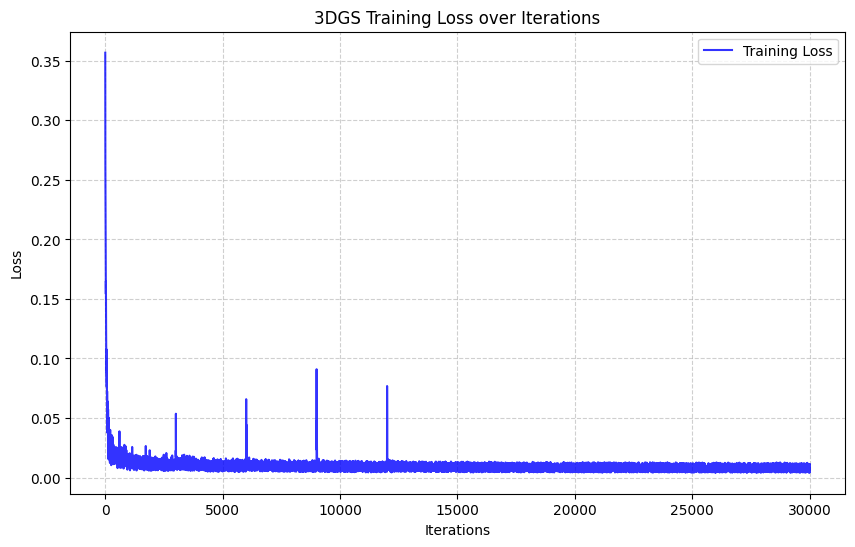

In [73]:
show_3DGS_loss_curve("/content/gaussian-splatting/output/vadim_try_on")

In [ ]:
# --- RESUME 3DGS LATER ---
# Fix PyTorch weights_only strict loading issue in train.py
!sed -i 's/torch.load(checkpoint)/torch.load(checkpoint, weights_only=False)/g' /content/gaussian-splatting/train.py

# If the colab disconnects or you want to train further (e.g., to 40k), you can run:
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on \
    --start_checkpoint /content/gaussian-splatting/output/vadim_try_on/chkpnt30000.pth \
    --checkpoint_iterations 100000 \
    --iterations 100000

Optimizing /content/gaussian-splatting/output/vadim_try_on
Output folder: /content/gaussian-splatting/output/vadim_try_on [20/05 22:18:17]
Reading camera 56/56 [20/05 22:18:18]
Loading Training Cameras [20/05 22:18:18]
Loading Test Cameras [20/05 22:18:18]
Number of points at initialisation :  3950 [20/05 22:18:18]
Training progress: 100% 70000/70000 [12:15<00:00, 95.19it/s, Loss=0.0163329]

[ITER 100000] Saving Gaussians [20/05 22:30:35]

[ITER 100000] Saving Checkpoint [20/05 22:30:36]

Training complete. [20/05 22:30:36]


In [ ]:
# Copy the specific training output folder to Google Drive
!cp -r /content/gaussian-splatting/output/vadim_try_on /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vadim_try_on_2_phase_splat_v2

# Freeze Pip versions

In [ ]:
!pip freeze > /content/requirements_locked.txt

# Expert LoRAs Training

### Installations

In [75]:
# Downgrade transformers to resolve 'torch.int1' compatibility issue with PyTorch 2.5.0
!pip install transformers==4.44.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 155.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.7 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.20.3
    Uninstalling tokenizers-0.20.3:
      Successfully uninstalled tokenizers-0.20.3
  Attempting uninstall: transformers
    Found existing installation: transformers 4.46.3
    Uninstalling transformers-4.46.3:
      Successfully uninstalled transformers-4.46.3


In [1]:
# Uninstall torchao to fix the torch.int1 compatibility issue with PyTorch 2.5.0
# PEFT will safely fall back to standard FP16 layers.
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


### Imports and utility functions

#### Determine body rotation angles from COLMAP

In [44]:
import os
import math
import json
import shutil
import struct
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

# Diffusers & PEFT
from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict
from transformers import CLIPTextModel, CLIPTokenizer
from accelerate import Accelerator

In [45]:
# ---------------------------------------------------------------------------
# 1. COLMAP Parsing Utilities
# ---------------------------------------------------------------------------
def qvec2rotmat(qvec):
    return np.array([
        [1 - 2 * qvec[2]**2 - 2 * qvec[3]**2,
         2 * qvec[1] * qvec[2] - 2 * qvec[0] * qvec[3],
         2 * qvec[3] * qvec[1] + 2 * qvec[0] * qvec[2]],
        [2 * qvec[1] * qvec[2] + 2 * qvec[0] * qvec[3],
         1 - 2 * qvec[1]**2 - 2 * qvec[3]**2,
         2 * qvec[2] * qvec[3] - 2 * qvec[0] * qvec[1]],
        [2 * qvec[3] * qvec[1] - 2 * qvec[0] * qvec[2],
         2 * qvec[2] * qvec[3] + 2 * qvec[0] * qvec[1],
         1 - 2 * qvec[1]**2 - 2 * qvec[2]**2]
    ])

def read_images_binary(path_to_model_file):
    """
    Reads the COLMAP images.bin file.
    Returns a dict mapping image_id to image info including name and Q, T.
    """
    images = {}
    with open(path_to_model_file, "rb") as fid:
        num_reg_images = struct.unpack("<Q", fid.read(8))[0]
        for _ in range(num_reg_images):
            binary_image_properties = struct.unpack("<idddddddi", fid.read(64))
            image_id = binary_image_properties[0]
            qvec = np.array(binary_image_properties[1:5])
            tvec = np.array(binary_image_properties[5:8])
            camera_id = binary_image_properties[8]
            image_name = ""
            current_char = struct.unpack("<c", fid.read(1))[0]
            while current_char != b"\x00":   # look for the null \0
                image_name += current_char.decode("utf-8")
                current_char = struct.unpack("<c", fid.read(1))[0]
            num_points2D = struct.unpack("<Q", fid.read(8))[0]
            # Skip 2D points (x, y, point3D_id) = 8 bytes + 8 bytes + 8 bytes = 24 bytes
            fid.seek(num_points2D * 24, 1)

            images[image_id] = {
                "name": image_name,
                "qvec": qvec,
                "tvec": tvec
            }
    return images

def calculate_azimuth(qvec, tvec, centroid=None):
    """
    Calculate the azimuthal angle (in degrees) of the camera relative to the origin.
    If centroid is provided, assumes the subject is centered at the given centroid.
    Camera center C = -R^T * T
    """
    R = qvec2rotmat(qvec)
    C = -np.dot(R.T, tvec)

    if centroid is not None:
        C = C - centroid

    # In COLMAP, standard coordinate system often has Y pointing down, Z forward.
    # The XZ plane is usually the ground plane.
    # Let's compute angle using atan2(x, z). Adjust this mapping if your world orientation differs.
    x, y, z = C
    angle_rad = math.atan2(x, z)
    angle_deg = math.degrees(angle_rad)

    # Normalize to 0-360
    if angle_deg < 0:
        angle_deg += 360
    return angle_deg

# ---------------------------------------------------------------------------
# 2. Dataset Partitioning
# ---------------------------------------------------------------------------

def get_colmap_angles(colmap_images_bin):
    """
    Extracts images from COLMAP and calculates their raw azimuth angles.
    """
    images_info = read_images_binary(colmap_images_bin)

    # Calculate centroid of all cameras
    centers = []
    for info in images_info.values():
        R = qvec2rotmat(info["qvec"])
        C = -np.dot(R.T, info["tvec"])
        centers.append(C)
    centroid = np.mean(centers, axis=0)
    print(f"Calculated camera centroid (new origin): {centroid}")

    # Calculate raw angles
    raw_angles = {}
    for img_id, info in images_info.items():
        raw_angles[info["name"]] = calculate_azimuth(info["qvec"], info["tvec"], centroid)

    return raw_angles

def shift_angles(raw_angles, anchor_image_name=None):
    """
    Shifts all angles so that the anchor_image_name is at 0 degrees.
    """
    shift_angle = 0
    if anchor_image_name and anchor_image_name in raw_angles:
        shift_angle = raw_angles[anchor_image_name]
        print(f"Anchoring front to {anchor_image_name} (Raw Angle: {shift_angle:.2f} deg). Shifting all angles by -{shift_angle:.2f} deg.")

    shifted_angles = {}
    for name, angle in raw_angles.items():
        shifted_angles[name] = (angle - shift_angle) % 360

    return shifted_angles

def create_partitions(shifted_angles, source_image_dir, output_dir):
    """
    Partitions images into Front, Side, and Back folders based on shifted azimuths.
    """
    partitions = {
        "front": [],
        "side": [],
        "back": []
    }

    os.makedirs(os.path.join(output_dir, "front"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "side"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "back"), exist_ok=True)

    for name, angle in shifted_angles.items():
        # Splatting the Cat partitions:
        # Front: -60 to 60 (or 300 to 360 and 0 to 60)
        # Back: 120 to 240
        # Side: 60 to 120, and 240 to 300

        if angle <= 60 or angle >= 300:
            category = "front"
        elif 120 <= angle <= 240:
            category = "back"
        else:
            category = "side"

        partitions[category].append(name)

        # Copy file
        src_path = os.path.join(source_image_dir, name)
        dst_path = os.path.join(output_dir, category, name)
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)

    print(f"\nDataset partitioned: Front({len(partitions['front'])}), Side({len(partitions['side'])}), Back({len(partitions['back'])})")
    for name in sorted(shifted_angles.keys()):
        print(f"Image: {name:<12} | Angle: {shifted_angles[name]:>6.2f} deg")
    return partitions


#### LoRA training function

In [70]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler, AutoencoderKL
from peft import LoraConfig, get_peft_model
from transformers import CLIPTextModel, CLIPTokenizer
from accelerate import Accelerator

def train_expert_lora(image_folder, output_dir, view_name,
                      rank=128, steps=2000, batch_size=1,
                      model_id="runwayml/stable-diffusion-inpainting"):
    print(f"\n--- Starting LoRA Training for {view_name.upper()} Expert ---")

    accelerator = Accelerator(mixed_precision="fp16")
    device = accelerator.device

    # Load SD Inpainting Pipeline components, including VAE
    tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
    vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
    unet = StableDiffusionInpaintPipeline.from_pretrained(model_id, subfolder="unet").unet.to(device)
    scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

    # Freeze base models
    text_encoder.requires_grad_(False)
    vae.requires_grad_(False)
    unet.requires_grad_(False)

    # Apply PEFT LoRA Config
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank,
        init_lora_weights="gaussian",
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    )
    unet = get_peft_model(unet, lora_config)
    unet.train()

    optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)

    # Dataloader
    image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_paths:
        print(f"No images found for {view_name}. Skipping.")
        return []

    # PRE-COMPUTE LATENTS AND WEIGHTS TO SPEED UP TRAINING
    print(f"Pre-computing latents for {len(image_paths)} images...")
    cached_data = []
    for img_path in image_paths:
        img = Image.open(img_path).convert("RGB").resize((512, 512))
        # Normalize to [-1, 1]
        clean_images = (torch.tensor(np.array(img)).float() / 127.5 - 1.0).permute(2, 0, 1).unsqueeze(0).to(device)

        with torch.no_grad():
            latents = vae.encode(clean_images).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        # 1. Create a binary weight mask where the original image is NOT black
        pixel_weight = (clean_images > -0.9).float()
        # 2. Downsample weight mask to match latent space
        latent_weight = F.interpolate(pixel_weight, size=latents.shape[2:], mode="bilinear", align_corners=False)
        # 3. Collapse RGB to single channel
        latent_weight = latent_weight.max(dim=1, keepdim=True)[0]

        cached_data.append((latents, latent_weight))

    def get_batch(bsz):
        # Randomly sample a batch of images from cached data
        indices = np.random.choice(len(cached_data), size=bsz, replace=True)
        batch_latents = torch.cat([cached_data[i][0] for i in indices], dim=0)
        batch_weights = torch.cat([cached_data[i][1] for i in indices], dim=0)
        return batch_latents, batch_weights

    # Prompt definition
    prompt = f"a photo of a {view_name} view person wearing a garment"
    text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
    text_embeddings = text_encoder(text_input.input_ids.to(device))[0]

    unet, optimizer = accelerator.prepare(unet, optimizer)

    losses = []
    for step in tqdm(range(steps), desc=f"Training {view_name}"):
        optimizer.zero_grad()

        latents, latent_weight = get_batch(batch_size)

        # Add noise to latents
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy_latents = scheduler.add_noise(latents, noise, timesteps)

        # --- FIX: Proper Masking for Inpainting ---
        # 1 = masked (to be inpainted), 0 = unmasked (context)
        mask = torch.zeros((bsz, 1, latents.shape[2], latents.shape[3]), device=device)
        for i in range(bsz):
            if torch.rand(1).item() < 0.25:
                # 25% chance to mask the entire image
                mask[i, :, :, :] = 1.0
            else:
                # Random rectangular mask covering a significant portion
                h, w = latents.shape[2], latents.shape[3]
                mask_h = torch.randint(h // 3, h, (1,)).item()
                mask_w = torch.randint(w // 3, w, (1,)).item()
                top = torch.randint(0, h - mask_h + 1, (1,)).item()
                left = torch.randint(0, w - mask_w + 1, (1,)).item()
                mask[i, :, top:top+mask_h, left:left+mask_w] = 1.0

        # Zero out the image latents where the mask is 1
        masked_image_latents = latents * (1.0 - mask)

        # Concatenate noisy_latents, mask, and masked_image_latents (4 + 1 + 4 = 9 channels)
        latent_model_input = torch.cat([noisy_latents, mask, masked_image_latents], dim=1)

        # Predict noise
        noise_pred = unet(latent_model_input, timesteps, encoder_hidden_states=text_embeddings.repeat(bsz, 1, 1)).sample

        # 4. Apply the pre-calculated weight to the prediction and the target
        # This forces the loss to be 0 for all background pixels
        weighted_noise_pred = noise_pred * latent_weight
        weighted_noise = noise * latent_weight

        # 5. Calculate MSE only on the weighted pixels
        loss = F.mse_loss(weighted_noise_pred, weighted_noise, reduction="mean")

        # Backprop
        accelerator.backward(loss)
        optimizer.step()

        losses.append(loss.item())

    # Save the trained LoRA
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"lora_expert_{view_name}")
    accelerator.unwrap_model(unet).save_pretrained(save_path)
    print(f"Saved {view_name} expert to {save_path}")
    return losses

### Split images into front/side/back folder to train different expert LoRAs

In [50]:
true_front_img_name = mp_true_front_img_name

In [51]:
# 2. Partition dataset while anchoring the new zero degree mark to the true front
COLMAP_BIN_PATH = "/content/gaussian-splatting/input/vadim/vanilla/sparse/0/images.bin"
SOURCE_IMAGES = "/content/gaussian-splatting/input/vadim/vanilla/images"
PARTITION_DIR = "/content/dataset_partitioned"

raw_angles = get_colmap_angles(COLMAP_BIN_PATH)
shifted_angles = shift_angles(raw_angles, anchor_image_name=true_front_img_name)
partitions = create_partitions(shifted_angles, SOURCE_IMAGES, PARTITION_DIR)

Calculated camera centroid (new origin): [    0.09762    0.038531    0.078974]
Anchoring front to 0011.jpg (Raw Angle: 90.01 deg). Shifting all angles by -90.01 deg.

Dataset partitioned: Front(17), Side(23), Back(18)
Image: 0001.jpg     | Angle:  61.04 deg
Image: 0002.jpg     | Angle:  58.57 deg
Image: 0003.jpg     | Angle:  54.87 deg
Image: 0004.jpg     | Angle:  49.79 deg
Image: 0005.jpg     | Angle:  41.77 deg
Image: 0006.jpg     | Angle:  35.61 deg
Image: 0007.jpg     | Angle:  29.46 deg
Image: 0008.jpg     | Angle:  20.15 deg
Image: 0009.jpg     | Angle:  12.97 deg
Image: 0010.jpg     | Angle:   6.48 deg
Image: 0011.jpg     | Angle:   0.00 deg
Image: 0012.jpg     | Angle: 352.16 deg
Image: 0013.jpg     | Angle: 344.66 deg
Image: 0014.jpg     | Angle: 337.26 deg
Image: 0015.jpg     | Angle: 330.32 deg
Image: 0016.jpg     | Angle: 322.67 deg
Image: 0017.jpg     | Angle: 315.03 deg
Image: 0018.jpg     | Angle: 307.33 deg
Image: 0019.jpg     | Angle: 299.77 deg
Image: 0020.jpg     | 

### Train view-expert LoRAs

In [62]:
LORA_OUTPUT_DIR = "/content/expert_loras"

all_losses = {}

# Train the 3 Experts based on the previously partitioned dataset
for view in ["side", "back"]: # , "side", "back"
    view_folder = os.path.join(PARTITION_DIR, view)
    if os.path.exists(view_folder):
        # Using batch_size=4 to better utilize GPU and stabilize gradients
        expert_losses = train_expert_lora(view_folder, LORA_OUTPUT_DIR, view, rank=64, steps=5000, batch_size=4)
        all_losses[view] = expert_losses
    else:
        print(f"Skipping {view}: folder {view_folder} does not exist.")


--- Starting LoRA Training for SIDE Expert ---


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
text_encoder/model.safetensors not found
Keyword arguments {'subfolder': 'unet'} are not expected by StableDiffusionInpaintPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Pre-computing latents for 26 images...


...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Pre-computing latents for 19 images...


Training back:   0%|          | 0/5000 [00:00<?, ?it/s]

Saved back expert to /content/expert_loras/lora_expert_back


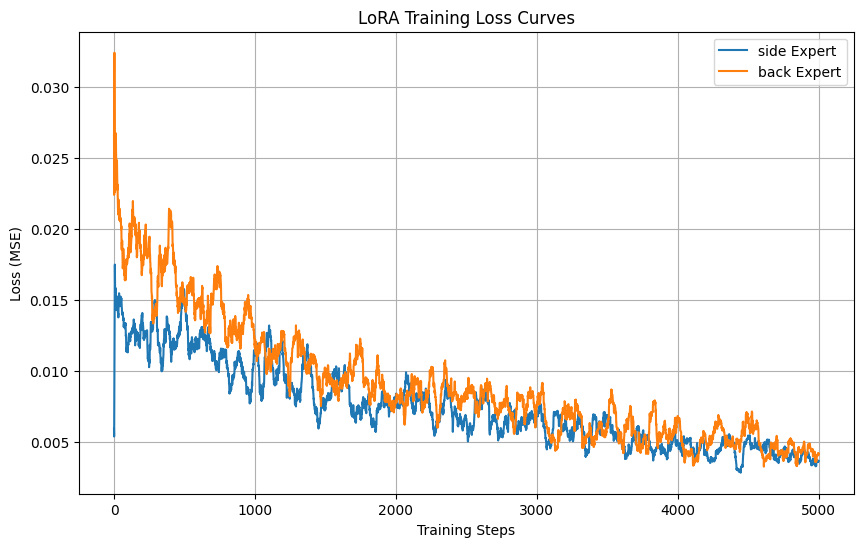

In [63]:
plt.figure(figsize=(10, 6))
for view, losses in all_losses.items():
    if losses:
        # Smooth the curve for better readability
        smoothed_losses = [np.mean(losses[max(0, i-50):i+1]) for i in range(len(losses))]
        plt.plot(smoothed_losses, label=f"{view} Expert")

plt.xlabel("Training Steps")
plt.ylabel("Loss (MSE)")
plt.title("LoRA Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [68]:
# save trained expert LoRAs to Google Drive
!mkdir -p /content/drive/MyDrive/weavella/LoRA_results/expert_loras
!tar -cf /content/drive/MyDrive/weavella/LoRA_results/expert_loras/expert_loras_v2.tar -C /content/ expert_loras

In [ ]:
# Download trained LoRAs
!mkdir -p /content/expert_loras
!gdown 1M6XwbIRfBFkZgeigyqFIcG0RPFNRdFdY -O /content/expert_loras/expert_loras_v2.tar
!tar -xf /content/expert_loras/expert_loras_v2.tar -C /content/expert_loras

### Generate image via expert LoRAs

text_encoder/model.safetensors not found


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280ae

Generating test image with 'front' expert LoRA...


  0%|          | 0/50 [00:00<?, ?it/s]

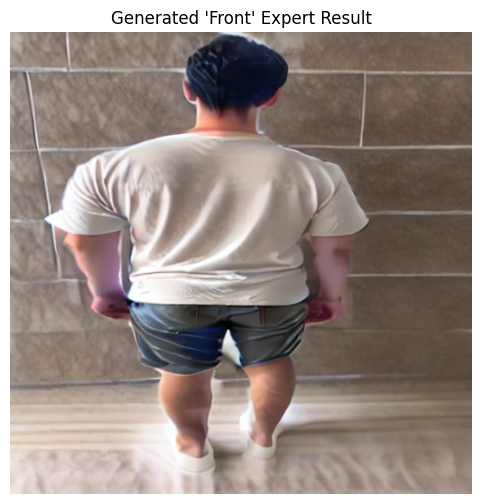

In [69]:
import torch
from diffusers import StableDiffusionInpaintPipeline
import matplotlib.pyplot as plt
from PIL import Image
from peft import PeftModel

# 1. Load the base pipeline
model_id = "runwayml/stable-diffusion-inpainting"
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")

# 2. Load the LoRA weights (testing the 'front' expert)
# Use PeftModel to load the adapter directly onto the UNet
lora_path = "/content/expert_loras/lora_expert_back"
pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_path)

# 3. Setup inputs
# Create a blank black image to match the training data background
init_image = Image.new("RGB", (512, 512), "black")
mask_image = Image.new("L", (512, 512), "white") # 255 = fully masked

prompt = "a photo of a front view person wearing a garment"
generator = torch.Generator("cuda").manual_seed(42)

# 4. Generate
print("Generating test image with 'front' expert LoRA...")
result = pipe(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=50, # increased inference steps for quality
    guidance_scale=7.5,
    generator=generator
).images[0]

# 5. Display
plt.figure(figsize=(6, 6))
plt.imshow(result)
plt.axis('off')
plt.title("Generated 'Front' Expert Result")
plt.show()

#### Remove background from the generated image